1.1 Load & Inspect

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/train.csv')

df.shape
df.head()
df.info()
df.describe()
df.dtypes.value_counts()  # How many numerical vs categorical


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

str        43
int64      35
float64     3
Name: count, dtype: int64

1.2 Target Variable Analysis

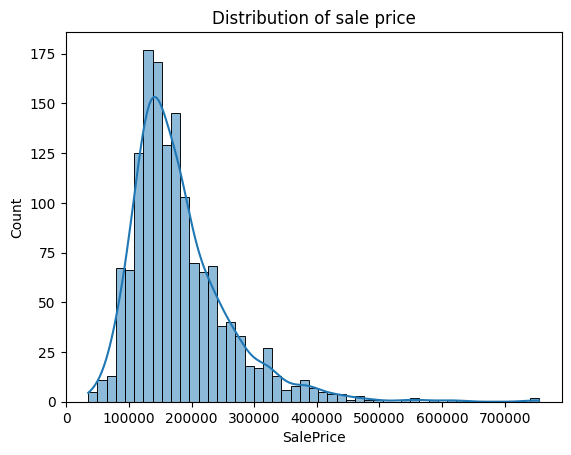

Skewness:1.88


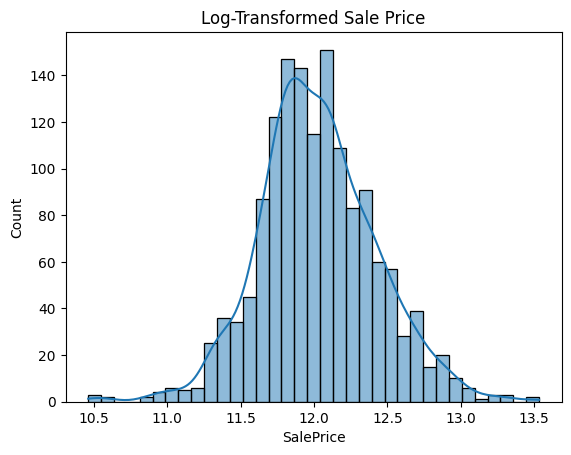

In [12]:
#Distribution of SalePrice (target)
sns.histplot(df['SalePrice'],kde=True)
plt.title('Distribution of sale price')
plt.show()

#Check skewness
print(f"Skewness:{df['SalePrice'].skew():.2f}")

#Log Transform check
sns.histplot(np.log1p(df['SalePrice']),kde=True)
plt.title('Log-Transformed Sale Price')
plt.show()

1.3 Missing Values Analysis

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


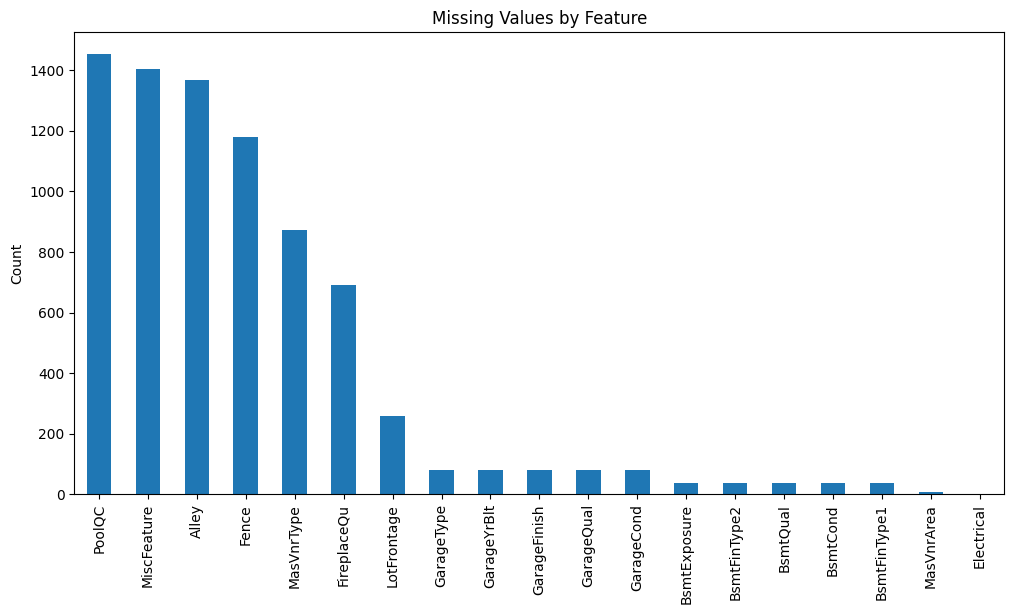

In [13]:
# Count missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

# Visualize
plt.figure(figsize=(12, 6))
missing.plot(kind='bar')
plt.title('Missing Values by Feature')
plt.ylabel('Count')
plt.show()

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


Text(0.5, 1.0, 'Correlation Heatmap — Top Features')

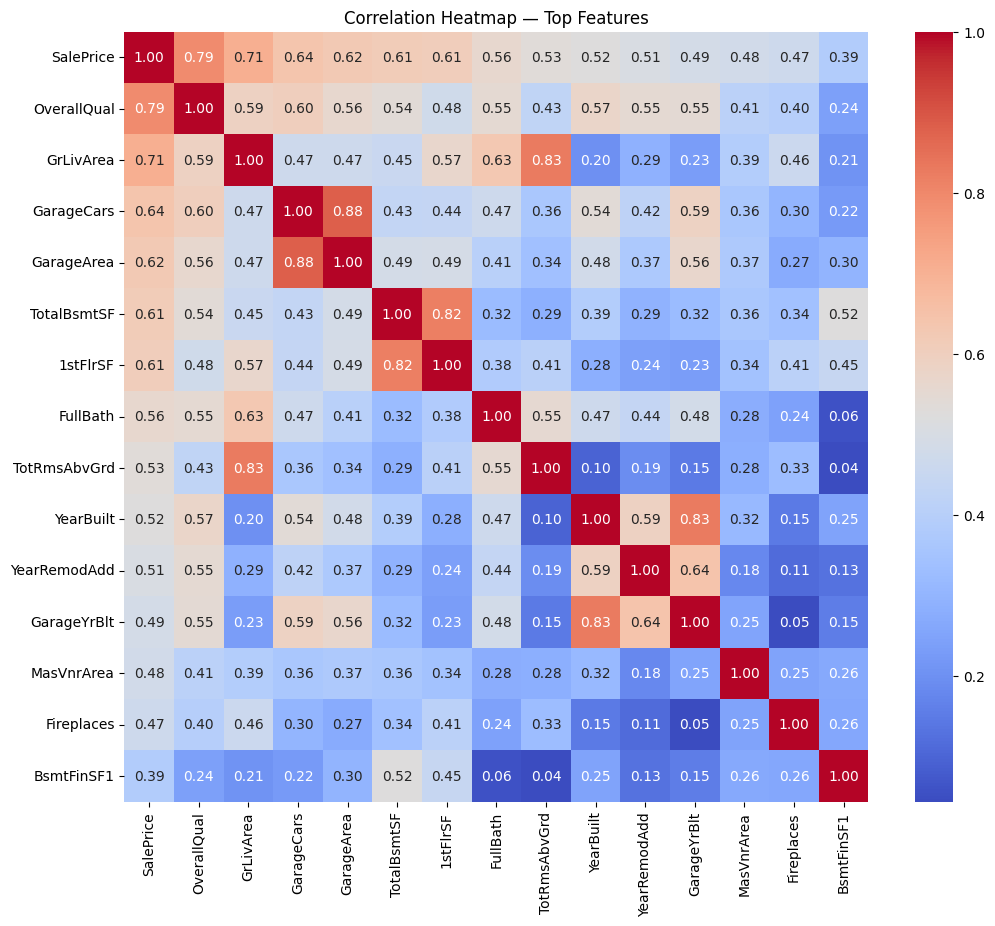

In [ ]:
# Top correlated features with SalePrice
corr = df.corr(numeric_only=True)
top_corr = corr['SalePrice'].sort_values(ascending=False).head(15)
print(top_corr)

# Heatmap of top features
plt.figure(figsize=(12, 10))
top_features = top_corr.index
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Top Features')

<Axes: title={'center': 'Sale Price by Neighborhood'}, xlabel='Neighborhood', ylabel='SalePrice'>

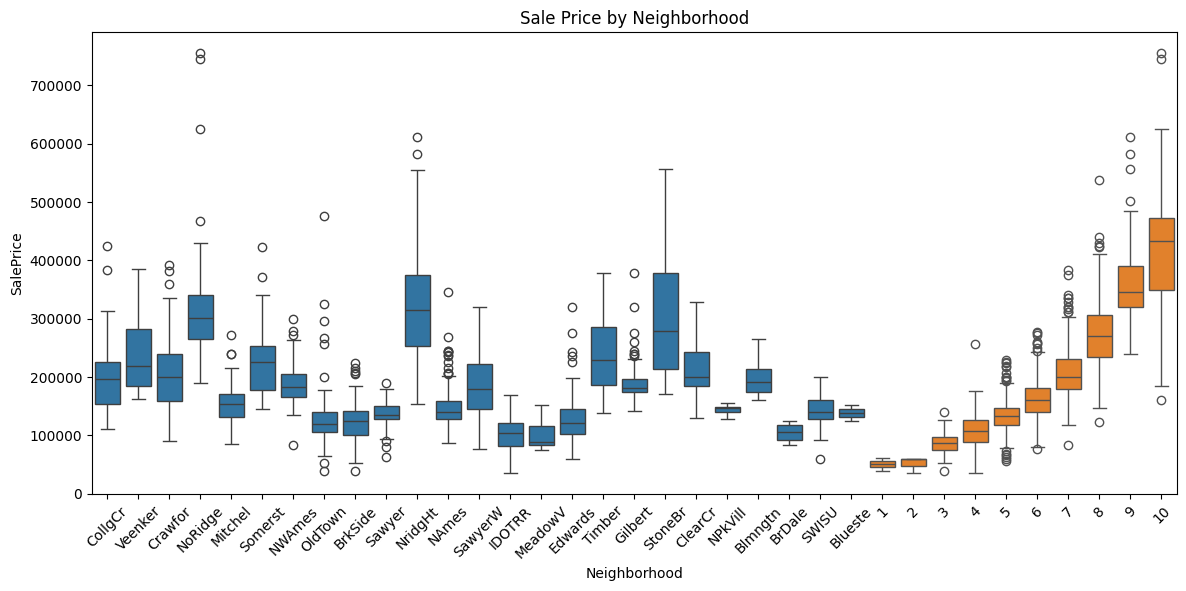

In [15]:
# Example: Neighborhood vs SalePrice
plt.figure(figsize=(14, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=45)
plt.title('Sale Price by Neighborhood')

# Overall Quality vs SalePrice
sns.boxplot(x='OverallQual', y='SalePrice', data=df)